In [2]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


# Загрузка данных

Датасет MathEdataset.csv содержит записи об ответах студентов на вопросы по математике 
Столбцы: Student ID, Student Country, Question ID, Type of Answer, Question Level, Topic, Subtopic, Keywords.  Целевая переменная: Type of Answer (0 - неверный ответ, 1 - верный ответ).

In [3]:
# Загружаем локальный датасет (разделитель — точка с запятой)
dataset = pd.read_csv('MathEdataset.csv', sep=';', encoding='latin-1')
dataset.head(10)


,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
0,647,Ireland,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
1,41,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
2,340,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
3,641,Italy,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
4,669,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
5,697,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
6,720,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
7,675,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
8,663,Portugal,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
9,28,Portugal,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."


# Анализ данных

In [4]:
# Размер датасета: количество записей и столбцов
dataset.shape


(9546, 8)

In [5]:
# Метод info() выводит информацию о датасете: количество записей, типы данных, ненулевые значения
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9546 entries, 0 to 9545
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Student ID       9546 non-null   int64 
 1   Student Country  9546 non-null   object
 2   Question ID      9546 non-null   int64 
 3   Type of Answer   9546 non-null   int64 
 4   Question Level   9546 non-null   object
 5   Topic            9546 non-null   object
 6   Subtopic         9546 non-null   object
 7   Keywords         9546 non-null   object
dtypes: int64(3), object(5)
memory usage: 596.8+ KB


In [6]:
# describe() - основная статистика числовых столбцов
dataset.describe()


,Student ID,Question ID,Type of Answer
count,9546.000000,9546.000000,9546.000000
mean,775.402263,478.912319,0.468259
std,460.590559,249.244061,0.499018
min,26.000000,77.000000,0.000000
25%,380.000000,323.000000,0.000000
50%,885.000000,428.000000,0.000000
75%,1219.000000,571.000000,1.000000
max,1565.000000,1549.000000,1.000000


In [7]:
# Уникальные значения целевой переменной
dataset['Type of Answer'].unique()


array([0, 1])

In [8]:
# Количество строк в каждом классе целевой переменной
dataset['Type of Answer'].value_counts()


Type of Answer
0    5076
1    4470
Name: count, dtype: int64

датасет содержит два класса. Если один класс значительно преобладает, то выборка несбалансирована, что важно учитывать при оценке моделей

# Визуализация данных

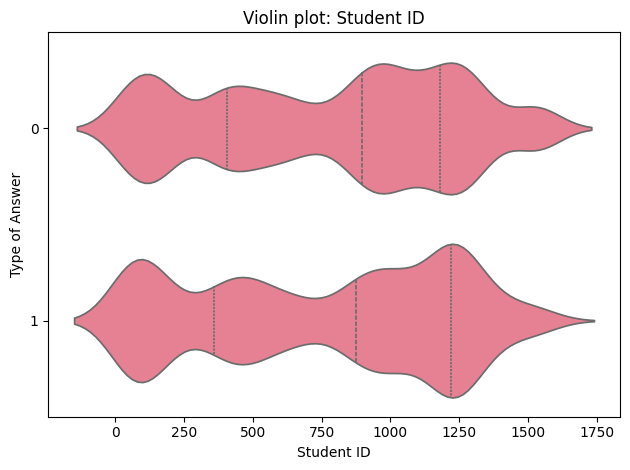

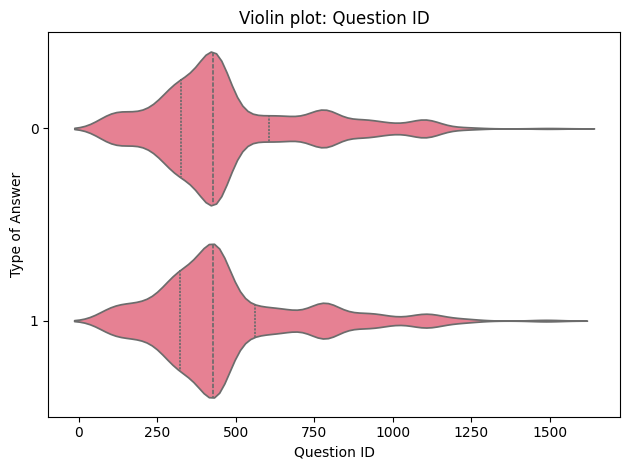

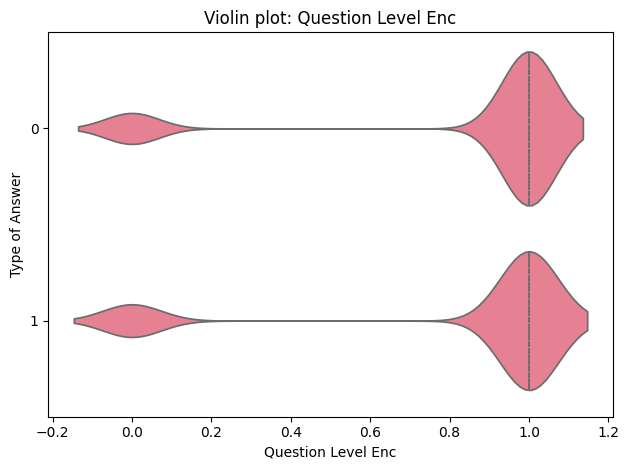

In [9]:
# Скрипичные графики для числовых признаков
# Используются для сравнения распределений по классам целевой переменной

numeric_cols = ['Student ID', 'Question ID', 'Question Level']

# Закодируем Question Level в числа для violin plot
le_level = LabelEncoder()
dataset['Question Level Enc'] = le_level.fit_transform(dataset['Question Level'])

for col in ['Student ID', 'Question ID', 'Question Level Enc']:
    sns.violinplot(y='Type of Answer', x=col, data=dataset, inner='quartile', orient='h')
    plt.title(f'Violin plot: {col}')
    plt.tight_layout()
    plt.show()


скрипичные графики показывают форму распределения каждого признака по классам. Если распределения сильно перекрываются, то признак слабо разделяет классы

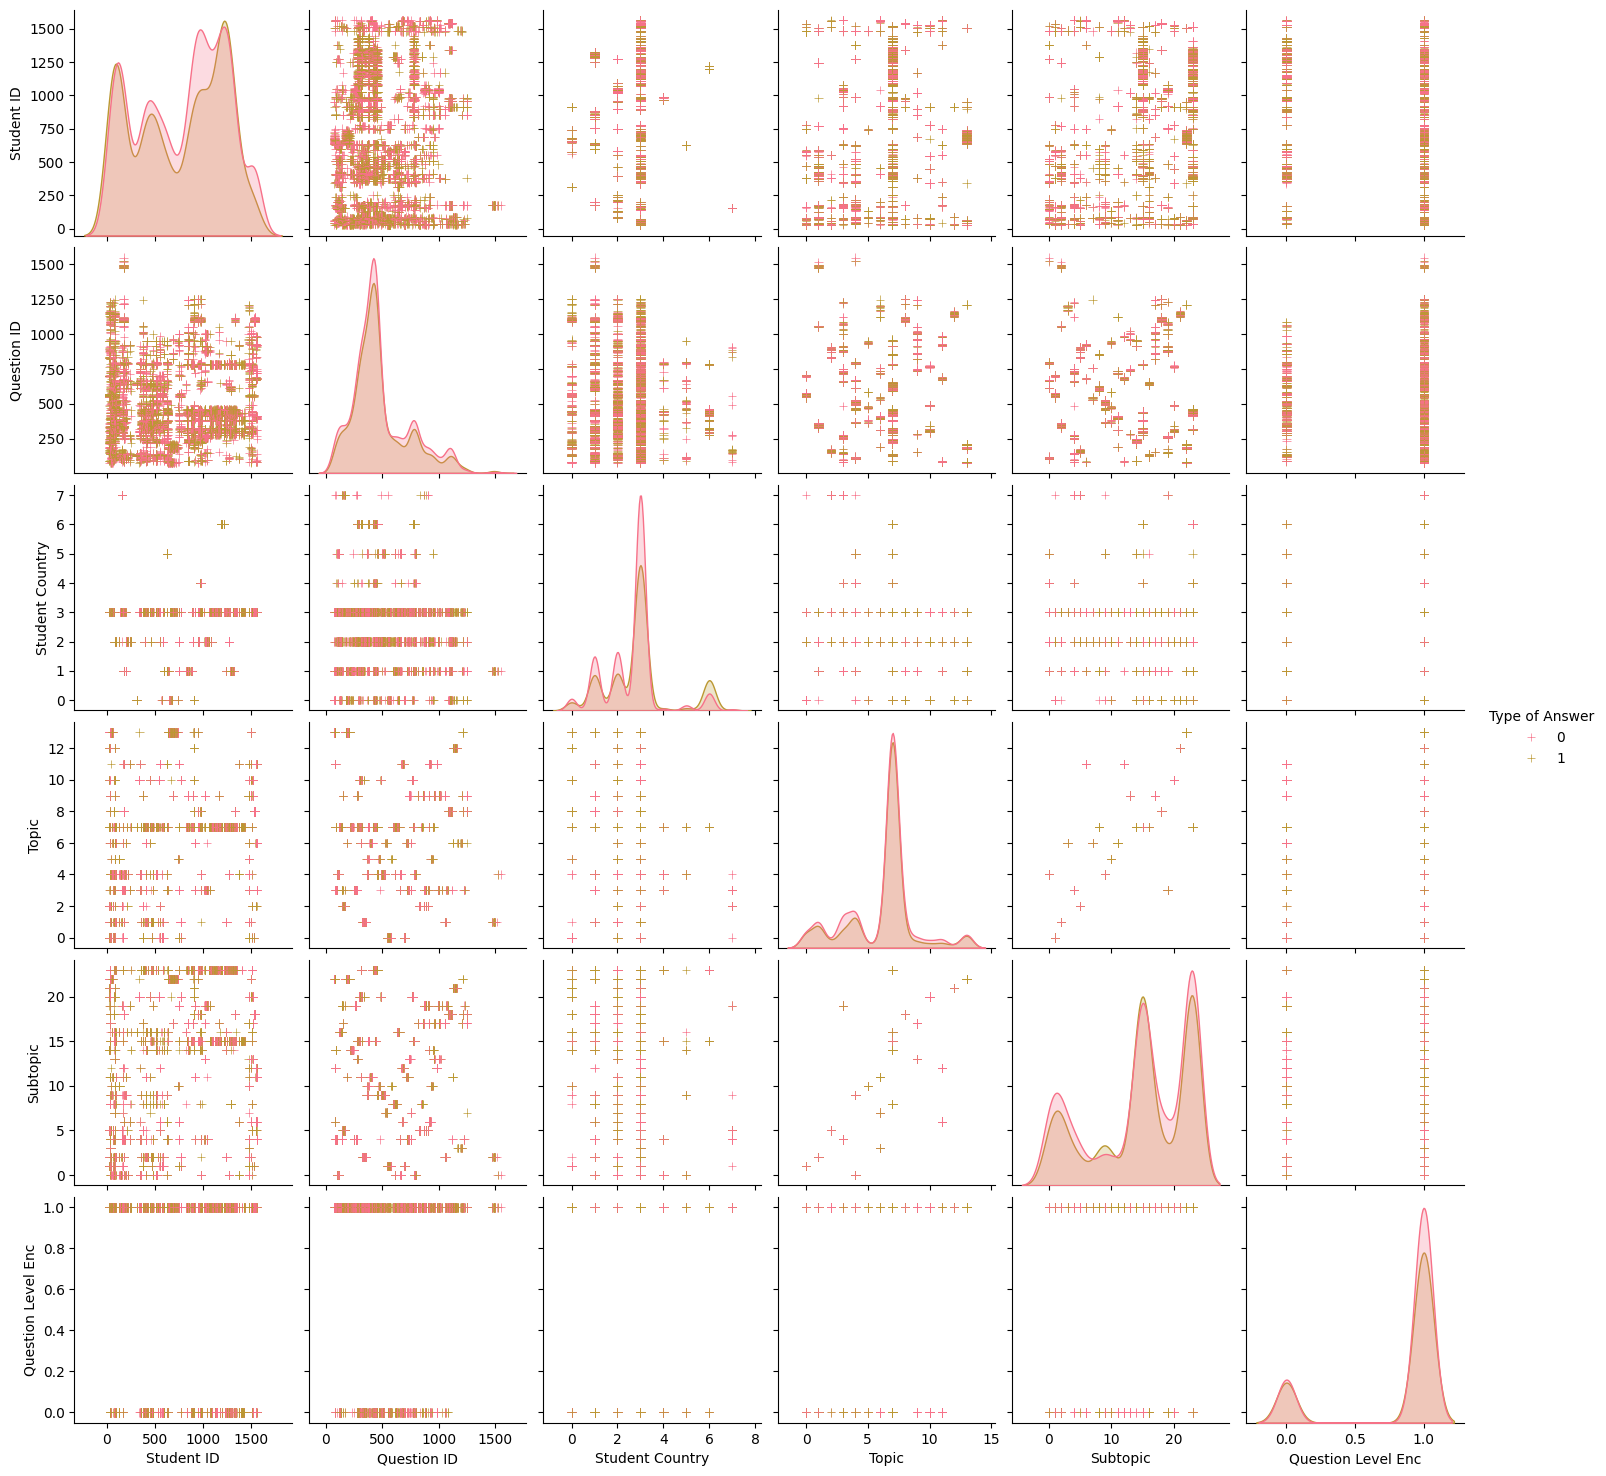

In [10]:
# Кодируем все категориальные столбцы для построения парного графика и тепловой карты
le_country = LabelEncoder()
le_topic = LabelEncoder()
le_subtopic = LabelEncoder()

dataset_enc = dataset.copy()
dataset_enc['Student Country'] = le_country.fit_transform(dataset['Student Country'])
dataset_enc['Topic'] = le_topic.fit_transform(dataset['Topic'])
dataset_enc['Subtopic'] = le_subtopic.fit_transform(dataset['Subtopic'])
dataset_enc = dataset_enc.drop(columns=['Keywords', 'Question Level'])

# Парный график
sns.pairplot(dataset_enc[['Student ID', 'Question ID', 'Student Country', 'Topic',
                           'Subtopic', 'Question Level Enc', 'Type of Answer']],
             hue='Type of Answer', markers='+')
plt.show()


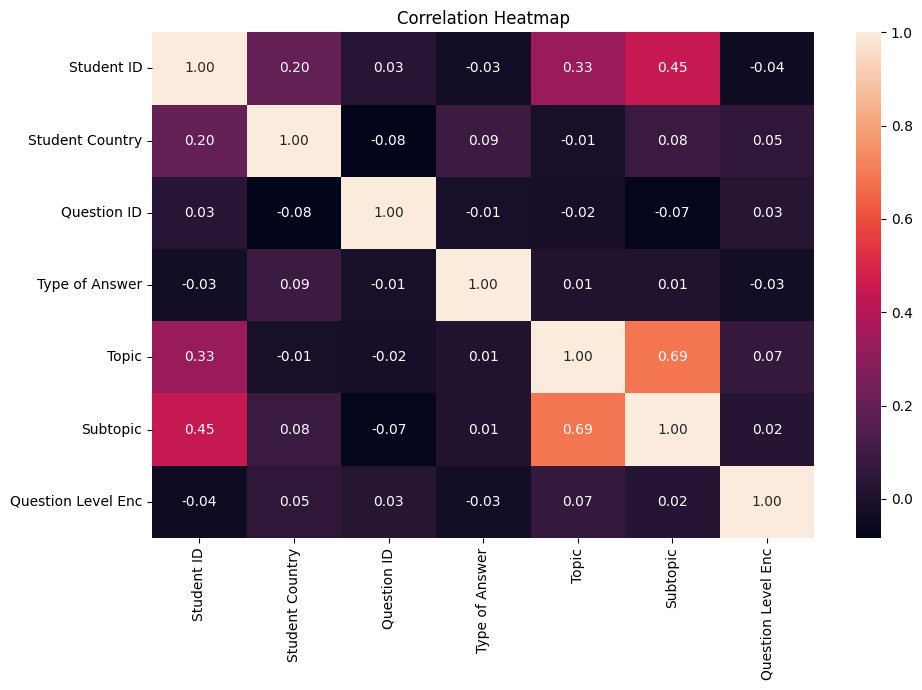

In [11]:
# Тепловая карта корреляций
plt.figure(figsize=(10, 7))
sns.heatmap(dataset_enc.corr(numeric_only=True), annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


тепловая карта показывает линейные корреляции между признаками. Высокая корреляция между двумя признаками (>0.8) может указывать на избыточность, значит один из них можно убрать

# Построение модели

## Разделение набора данных

Y - целевая переменная Type of Answer (0 = неверный, 1 = верный).  
X - все остальные числовые признаки после кодирования категориальных столбцов.

In [12]:
feature_cols = ['Student ID', 'Question ID', 'Student Country', 'Topic',
                'Subtopic', 'Question Level Enc']

X = dataset_enc[feature_cols]
y = dataset_enc['Type of Answer']

print(f'X shape: {X.shape} | y shape: {y.shape}')


X shape: (9546, 6) | y shape: (9546,)


## Train/Test разделение

Разделяем набор данных: 80 % - обучающая выборка, 20 % - тестовая 
Параметр stratify обеспечивает одинаковое соотношение классов в обеих выборках

In [13]:
import scipy.stats as stats

feature_cols = ['Student ID', 'Question ID', 'Student Country', 'Topic',
                'Subtopic', 'Question Level Enc']

X = dataset_enc[feature_cols]
y = dataset_enc['Type of Answer']

print(f'X shape: {X.shape} | y shape: {y.shape}')

# Проверяем, что train и test статистически неразличимы по целевой переменной (без стратификации)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, shuffle=True)
stats.ttest_ind(a=y_train, b=y_test)


X shape: (9546, 6) | y shape: (9546,)


TtestResult(statistic=np.float64(-1.6967184126227475), pvalue=np.float64(0.089782518021756), df=np.float64(9544.0))

In [14]:
# Со стратификацией: гарантируем одинаковое соотношение классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=15, stratify=y)

stats.ttest_ind(a=y_train, b=y_test)


TtestResult(statistic=np.float64(0.019204301786566666), pvalue=np.float64(0.9846785273488532), df=np.float64(9544.0))

## Обучение и выбор оптимальной модели

Попробуем следующие алгоритмы:

- Logistic Regression (LR)
- Linear Discriminant Analysis (LDA)
- K-Nearest Neighbors (KNN)
- Classification and Regression Trees (CART)
- Gaussian Naive Bayes (NB)
- Support Vector Machines (SVM)

In [22]:
# Создаём список моделей для сравнения
models = []
models.append(('LR',   LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA',  LinearDiscriminantAnalysis()))
models.append(('KNN',  KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB',   GaussianNB()))
models.append(('SVC',  SVC(gamma='auto')))

# Оцениваем модели через кросс-валидацию
results = []
model_names = []
for name, model in models:
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    model_names.append(name)
    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))


LR: 0.555665 (0.019053)
LDA: 0.555796 (0.019151)
KNN: 0.603328 (0.016042)
CART: 0.611575 (0.013735)
NB: 0.555264 (0.012444)
SVC: 0.613548 (0.017692)


модель с наибольшей средней точностью (mean) и наименьшим разбросом (std) является наиболее стабильной и предпочтительной. Именно её выбираем для дальнейшего обучения.

## Обучение конкретной модели

Выбираем лучшую модель по результатам кросс-валидации и обучаем её на полном обучающем наборе

In [16]:
sk_lda = LinearDiscriminantAnalysis(solver='eigen')
sk_lda.fit(X_train, y_train)
sk_lda_pred_res = sk_lda.predict(X_test)
sk_transformed = sk_lda.transform(X_train)
sk_lda_accuracy = accuracy_score(y_test, sk_lda_pred_res)

print(f'sk LDA accuracy: {sk_lda_accuracy}')
print(f'sk LDA prediction (first 20): {sk_lda_pred_res[:20]}')
print('sk transformed features (first 5):')
print(sk_transformed[:5].T)


sk LDA accuracy: 0.5732984293193717
sk LDA prediction (first 20): [1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0]
sk transformed features (first 5):
[[-0.56683018 -0.21748379  0.53410705 -0.73307045 -0.79524236]]


LDA не только классифицирует, но и проецирует данные в пространство меньшей размерности. sk_transformed это новые признаки после LDA-преобразования

## Визуализация решения

Так как задача бинарная, LDA проецирует данные на 1 ось. Для построения границы решения используем два числовых признака: Question ID и Student Country

In [ ]:
!pip install mlxtend


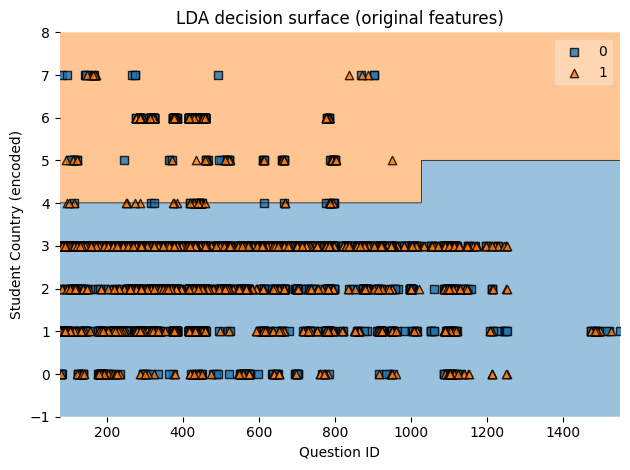

In [18]:
from mlxtend.plotting import plot_decision_regions

X_2d = X_train[['Question ID', 'Student Country']].values
y_2d = y_train.values

sk_lda1 = LinearDiscriminantAnalysis(solver='eigen')
sk_lda1.fit(X_2d, y_2d)

plt.title('LDA decision surface (original features)')
plot_decision_regions(X=X_2d, y=y_2d, clf=sk_lda1)
plt.xlabel('Question ID')
plt.ylabel('Student Country (encoded)')
plt.tight_layout()
plt.show()


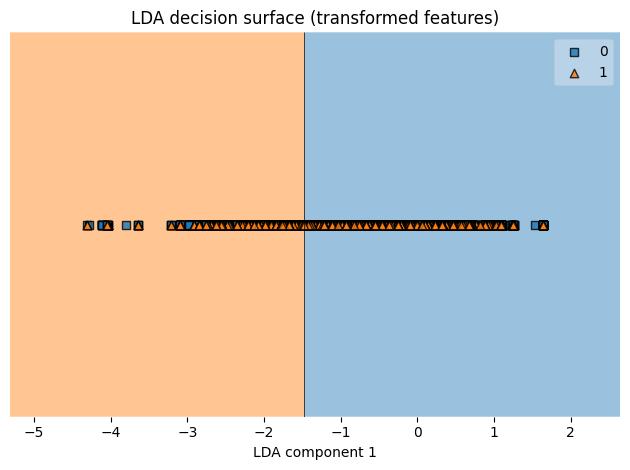

In [19]:
# LDA-преобразование всего набора и повторный plot_decision_regions на трансформированных признаках
ys_all = y.values
X1_lda = sk_lda.fit(X, ys_all).transform(X)

X1_lda_train, X1_lda_test, y1_train, y1_test = train_test_split(
    X1_lda, ys_all, random_state=0)

sk_lda2 = LinearDiscriminantAnalysis(solver='eigen')
sk_lda2.fit(X1_lda_train, y1_train)

plt.title('LDA decision surface (transformed features)')
plot_decision_regions(X=X1_lda, y=ys_all, clf=sk_lda2)
plt.xlabel('LDA component 1')
plt.tight_layout()
plt.show()


In [20]:
predicted = sk_lda2.predict(X1_lda_test)


In [21]:
from sklearn import metrics

# Метрики на тестовом наборе
accuracy  = metrics.accuracy_score(y1_test, predicted)
recall    = metrics.recall_score(y1_test, predicted, average='weighted')
precision = metrics.precision_score(y1_test, predicted, average='weighted')

print("Recall  (all 1s predicted right):", round(recall,    2))
print("Precision (confidence when predicting a 1):", round(precision, 2))
print("Accuracy:", round(accuracy, 2))
print("\nDetail:")
print(metrics.classification_report(
    y1_test, predicted,
    target_names=[str(i) for i in np.unique(y1_test)]))


Recall  (all 1s predicted right): 0.54
Precision (confidence when predicting a 1): 0.54
Accuracy: 0.54

Detail:
              precision    recall  f1-score   support

           0       0.55      0.74      0.63      1263
           1       0.52      0.31      0.39      1124

    accuracy                           0.54      2387
   macro avg       0.54      0.53      0.51      2387
weighted avg       0.54      0.54      0.52      2387



  
- Accuracy -доля верных предсказаний на тестовой выборке  
- Precision - насколько точны позитивные предсказания модели  
- Recall - какую долю истинных случаев модель нашла  

Чем ближе все три метрики к 1.0, тем лучше модель. При дисбалансе классов смотрим прежде всего на F1-score из classification_report